In [4]:
from google.colab import files
uploaded = files.upload()

Saving Food_Delivery_Times.csv to Food_Delivery_Times.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import pandas as pd

df = pd.read_csv("Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [7]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

Does traffic level change how distance affects delivery time?

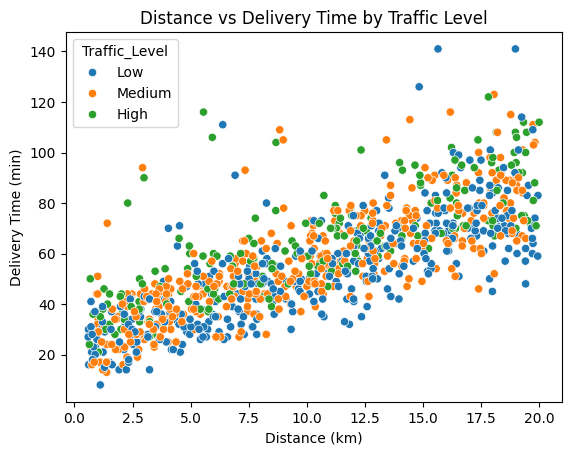

In [8]:
plt.figure()

sns.scatterplot(
    data=df,
    x="Distance_km",
    y="Delivery_Time_min",
    hue="Traffic_Level"
)

plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.title("Distance vs Delivery Time by Traffic Level")

plt.show()

How much additional delivery time is caused by traffic compared to distance?

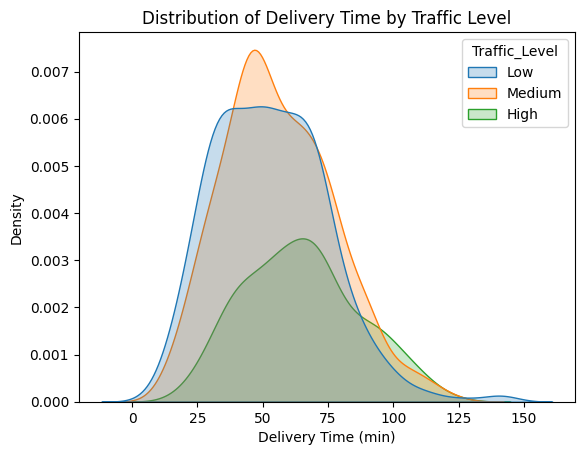

In [9]:
plt.figure()

sns.kdeplot(
    data=df,
    x="Delivery_Time_min",
    hue="Traffic_Level",
    fill=True
)

plt.xlabel("Delivery Time (min)")
plt.ylabel("Density")
plt.title("Distribution of Delivery Time by Traffic Level")

plt.show()

In [12]:
from sklearn.linear_model import LinearRegression

df["Traffic_Code"] = df["Traffic_Level"].astype("category").cat.codes

X = df[["Distance_km", "Traffic_Code"]]
y = df["Delivery_Time_min"]

model = LinearRegression()
model.fit(X, y)

print("Distance coefficient:", model.coef_[0])
print("Traffic coefficient:", model.coef_[1])
print("Intercept:", model.intercept_)

Distance coefficient: 2.958525977570445
Traffic coefficient: -2.0538792563163217
Intercept: 29.146551680295573
